# **Day 96: Project 5 - Forest Above-Ground Biomass: Regression, Uncertainty and Carbon Totals**
*Module 13 - Remote Sensing ML and Publication Projects*

Biomass and carbon maps feed national greenhouse-gas inventories, REDD+ and carbon markets. In these uses, the **uncertainty** matters as much as the estimate: IPCC good practice asks for estimates that are "neither over- nor underestimated so far as can be judged, and in which uncertainties are reduced as far as practicable".

> **Working title**: *Mapping above-ground biomass of dry deciduous forests from Sentinel-1/2 and canopy-height data, with conformal prediction intervals and model-assisted carbon totals.*

**Research questions**
- **RQ1**: How accurately can AGB be predicted, and where does the signal **saturate**?
- **RQ2**: Can we attach pixel-level **prediction intervals** with honest coverage?
- **RQ3**: What is the total AGB and carbon stock of the wooded area, with a valid 95% confidence interval?

> Biomass (the weight of vegetation per hectare) is predicted from satellite data and field plots. We report the error, give each pixel an uncertainty range, and estimate the total carbon with a confidence interval.
>
> *Example:* A forest pixel predicted at 150 Mg/ha with a range of 110-190 Mg/ha is honest; the total carbon of the district is reported as a value plus or minus its error.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
import lightgbm as lgb
import rs_utils as ru
ru.pub_style()
PROJ = Path("project5_biomass"); PROJ.mkdir(exist_ok=True)
SEED = 42; rng = np.random.default_rng(SEED)

## **1. Data**
- **Field plots**: 250 plots of about 0.04 ha (one 20 m pixel), placed by simple random sampling in the wooded area (forest and shrubland). AGB comes from tree measurements and allometric equations (Chave et al. 2014), with about 12% error, and a GPS error that puts a quarter of the plots one pixel off.
- **Predictors** (20 m): S2 NDVI, NDRE and B11; S1 VH and VV; NIR texture; terrain; and a **canopy-height product** (for example a GEDI-calibrated global canopy-height map such as Lang et al. 2023).

250 plots | AGB mean 56.5, median 50.5, max 214.8 Mg/ha | wooded area 2,506 ha


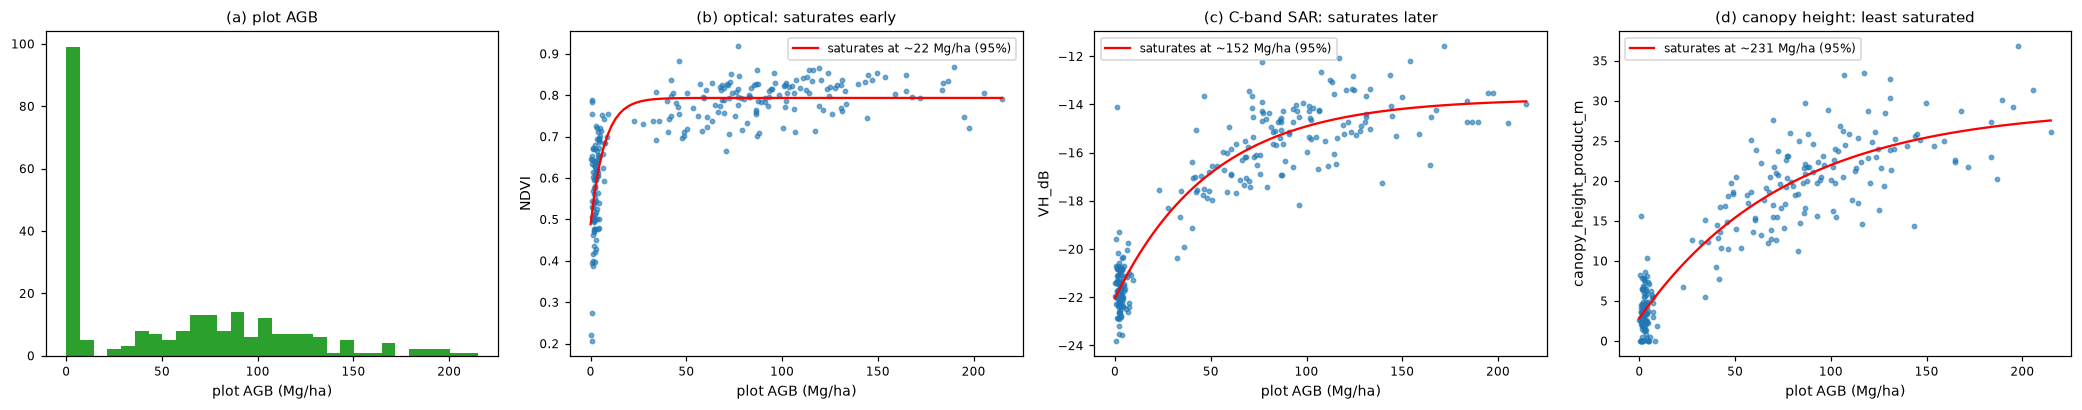

In [2]:
area = ru.make_biomass_area(seed=5)
Pr, agb_true, wooded, plots, T = area["predictors"], area["agb_true"], area["wooded"], area["plots"], area["transform"]
H, W = agb_true.shape; PIX_HA = 0.04; ext = ru.map_extent(T, (H, W))
feat_s12 = ["NDVI", "NDRE", "B11", "VH_dB", "VV_dB", "NIR_texture", "elevation_m", "slope_deg"]
feat_all = feat_s12 + ["canopy_height_product_m"]
df = plots.copy()
for k, v in Pr.items(): df[k] = v[df.row, df.col]
df["block"] = ru.spatial_blocks(df.x, df.y, 1000)
y = df["agb_Mg_ha"].values
print(f"{len(df)} plots | AGB mean {y.mean():.1f}, median {np.median(y):.1f}, max {y.max():.1f} Mg/ha | wooded area {wooded.sum() * PIX_HA:,.0f} ha")

sat = lambda x, a, b, c: a + b * (1 - np.exp(-x / c))
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
axes[0].hist(y, 30, color="tab:green"); axes[0].set_xlabel("plot AGB (Mg/ha)"); axes[0].set_title("(a) plot AGB")
for ax, f in zip(axes[1:], ["NDVI", "VH_dB", "canopy_height_product_m"]):
    ax.scatter(y, df[f], s=8, alpha=0.6)
    try:
        pp, _ = curve_fit(sat, y, df[f], p0=[df[f].min(), np.ptp(df[f]), 50], maxfev=20000)
        xx = np.linspace(0, y.max(), 100); ax.plot(xx, sat(xx, *pp), "r-", label=f"saturates at ~{3 * pp[2]:.0f} Mg/ha (95%)"); ax.legend(fontsize=8)
    except RuntimeError:
        pass
    ax.set_xlabel("plot AGB (Mg/ha)"); ax.set_ylabel(f)
axes[1].set_title("(b) optical: saturates early"); axes[2].set_title("(c) C-band SAR: saturates later"); axes[3].set_title("(d) canopy height: least saturated")
plt.tight_layout(); fig.savefig(PROJ / "fig1_saturation.png", dpi=300, bbox_inches="tight"); plt.show()

## **2. Models under Spatial CV (Table 1)**
Metrics used in biomass papers:
- **RMSE** and **relative RMSE** (RMSE / mean observed AGB)
- **bias** (mean of predicted - observed)
- **R²**
- the bias **per AGB class**, which reveals saturation: high AGB is under-predicted and low AGB over-predicted (regression to the mean)

The models are a log-linear model (the classic approach, with a back-transformation bias correction), random forest and LightGBM, each with and without the canopy-height product.

In [3]:
groups = df["block"].values
folds = list(GroupKFold(5).split(df, y, groups))

class LogLinear:
    """ln(AGB + 1) = X b + e; back-transform with the Baskerville correction exp(s^2 / 2)."""
    def fit(self, X, y):
        self.m = LinearRegression().fit(X, np.log1p(y)); r = np.log1p(y) - self.m.predict(X); self.cf = np.exp(r.var(ddof=X.shape[1] + 1) / 2); return self
    def predict(self, X):
        return np.expm1(self.m.predict(X)) * self.cf

model_defs = {"log-linear": lambda: LogLinear(),
              "random forest": lambda: RandomForestRegressor(500, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=SEED),
              "LightGBM": lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=10, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=SEED)}

def metrics(obs, pred):
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    return {"RMSE": rmse, "rRMSE %": 100 * rmse / obs.mean(), "bias": np.mean(pred - obs), "R2": 1 - np.sum((pred - obs) ** 2) / np.sum((obs - obs.mean()) ** 2)}

oof, rows = {}, []
for fname, feats in [("S1+S2", feat_s12), ("S1+S2+CHM", feat_all)]:
    X = df[feats].values
    for mname, mk in model_defs.items():
        p = np.zeros(len(y))
        for tr, te in folds: p[te] = mk().fit(X[tr], y[tr]).predict(X[te])
        oof[(mname, fname)] = p; rows.append({"model": mname, "features": fname, **metrics(y, p)})
table1 = pd.DataFrame(rows).set_index(["model", "features"]); table1.round(3).to_csv(PROJ / "table1_models.csv"); table1.round(2)

,,RMSE,rRMSE %,bias,R2
model,features,,,,
log-linear,S1+S2,38.16,67.58,8.42,0.52
random forest,S1+S2,22.99,40.71,0.20,0.82
LightGBM,S1+S2,23.15,40.99,0.36,0.82
log-linear,S1+S2+CHM,39.62,70.16,9.09,0.48
random forest,S1+S2+CHM,21.22,37.57,0.13,0.85
LightGBM,S1+S2+CHM,21.86,38.72,0.65,0.84


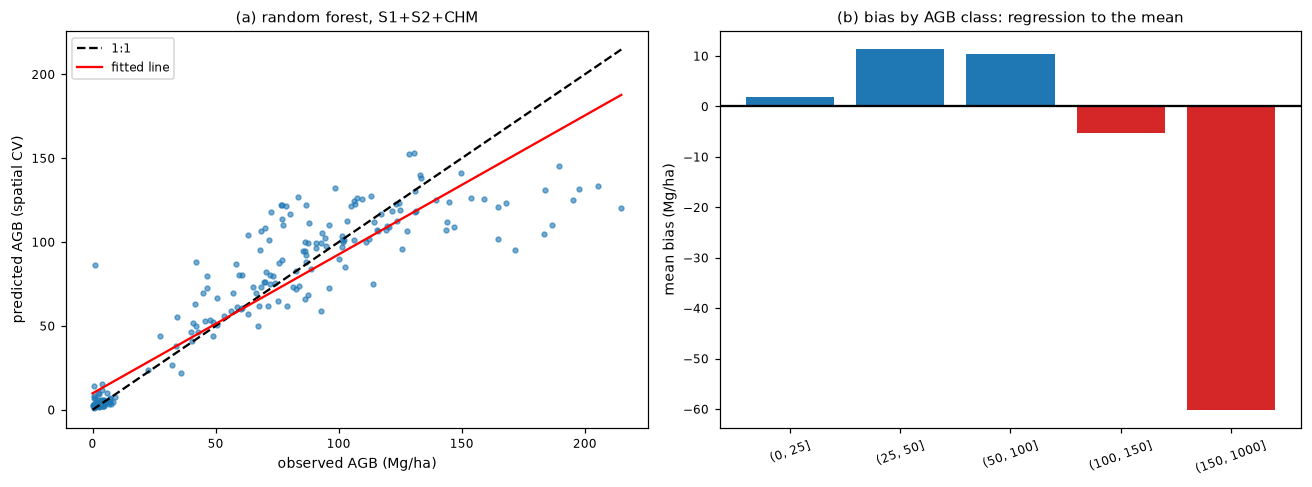

,n,bias,rRMSE %
class,,,
"(0, 25]",104.0,1.87,292.31
"(25, 50]",19.0,11.29,44.16
"(50, 100]",67.0,10.41,28.03
"(100, 150]",45.0,-5.20,13.67
"(150, 1000]",14.0,-60.14,34.75


In [4]:
best_key = table1["RMSE"].idxmin(); p_best = oof[best_key]
bins = [0, 25, 50, 100, 150, 1000]; cls = pd.cut(y, bins)
by_class = pd.DataFrame({"obs": y, "pred": p_best, "class": cls}).groupby("class", observed=True).apply(
    lambda g: pd.Series({"n": len(g), "bias": (g.pred - g.obs).mean(), "rRMSE %": 100 * np.sqrt(((g.pred - g.obs) ** 2).mean()) / g.obs.mean()}), include_groups=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y, p_best, s=10, alpha=0.6); axes[0].plot([0, y.max()], [0, y.max()], "k--", label="1:1")
axes[0].plot(np.sort(y), np.poly1d(np.polyfit(y, p_best, 1))(np.sort(y)), "r-", label="fitted line")
axes[0].set_xlabel("observed AGB (Mg/ha)"); axes[0].set_ylabel("predicted AGB (spatial CV)"); axes[0].legend(); axes[0].set_title(f"(a) {best_key[0]}, {best_key[1]}")
axes[1].bar(range(len(by_class)), by_class["bias"], color=np.where(by_class["bias"] < 0, "tab:red", "tab:blue"))
axes[1].set_xticks(range(len(by_class)), [str(i) for i in by_class.index], rotation=20); axes[1].axhline(0, c="k")
axes[1].set_ylabel("mean bias (Mg/ha)"); axes[1].set_title("(b) bias by AGB class: regression to the mean")
plt.tight_layout(); fig.savefig(PROJ / "fig2_obs_pred.png", dpi=300, bbox_inches="tight"); plt.show()
by_class.round(2)

## **3. Prediction Intervals with Honest Coverage**
A point map is not enough: users need to know how far to trust each pixel. We compare three ways to build 90% intervals, all evaluated under the same **spatial** CV. Inside each training fold, 25% of the blocks are held out as a **calibration set**.
- **Split conformal around RF** (Day 77): interval = prediction +/- the (1 - alpha) quantile of |calibration residuals|. Coverage is guaranteed under exchangeability, but every pixel gets the same width.
- **Quantile LightGBM**: fit the 5% and 95% quantiles directly. The width adapts to each pixel, but coverage is not guaranteed.
- **CQR** (Romano et al. 2019): adapt the quantile interval using conformity scores E = max(q_lo - y, y - q_hi) on the calibration set. It is adaptive, and calibrated whenever calibration and test data are exchangeable.

Spatial autocorrelation weakens exchangeability, so the coverage must be **checked** on spatially held-out data, as here.

In [5]:
ALPHA = 0.10; X = df[feat_all].values
def qlgb(alpha):
    return lgb.LGBMRegressor(objective="quantile", alpha=alpha, n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=10, verbose=-1, random_state=SEED)

def conformal_q(scores, alpha):
    n = len(scores); return np.quantile(scores, min(1, np.ceil((n + 1) * (1 - alpha)) / n))

res_int = {m: {"cover": [], "width": []} for m in ["split conformal (RF)", "quantile LightGBM", "CQR (LightGBM)"]}
for tr, te in folds:
    blk = np.unique(groups[tr]); cal_blk = rng.choice(blk, max(1, len(blk) // 4), replace=False)
    cal = tr[np.isin(groups[tr], cal_blk)]; prop = tr[~np.isin(groups[tr], cal_blk)]
    rf = model_defs["random forest"]().fit(X[prop], y[prop])
    qhat = conformal_q(np.abs(y[cal] - rf.predict(X[cal])), ALPHA); pt = rf.predict(X[te])
    intervals = {"split conformal (RF)": (pt - qhat, pt + qhat)}
    lo, hi = qlgb(ALPHA / 2).fit(X[prop], y[prop]), qlgb(1 - ALPHA / 2).fit(X[prop], y[prop])
    intervals["quantile LightGBM"] = (lo.predict(X[te]), hi.predict(X[te]))
    E = np.maximum(lo.predict(X[cal]) - y[cal], y[cal] - hi.predict(X[cal])); qc = conformal_q(E, ALPHA)
    intervals["CQR (LightGBM)"] = (lo.predict(X[te]) - qc, hi.predict(X[te]) + qc)
    for m, (a, b) in intervals.items():
        res_int[m]["cover"].append(np.mean((y[te] >= a) & (y[te] <= b))); res_int[m]["width"].append(np.mean(np.clip(b, 0, None) - np.clip(a, 0, None)))
table2 = pd.DataFrame({m: {"coverage (target 0.90)": np.mean(v["cover"]), "coverage s.d. over folds": np.std(v["cover"]), "mean width (Mg/ha)": np.mean(v["width"])} for m, v in res_int.items()}).T
table2.round(3).to_csv(PROJ / "table2_intervals.csv")
table2.round(3)

,coverage (target 0.90),coverage s.d. over folds,mean width (Mg/ha)
split conformal (RF),0.844,0.122,48.173
quantile LightGBM,0.672,0.068,38.460
CQR (LightGBM),0.815,0.125,53.271


How to read Table 2:
- **Raw quantile regression** gives narrow intervals that miss the truth far too often: its coverage is well below 90%.
- **Conformal calibration** (split conformal and CQR) widens the intervals and raises the coverage substantially. That is its job.
- Under **spatial** cross-validation the coverage can still fall short of the 90% target, and it varies a lot between folds. The calibration plots and the test plots come from different places, and spatially clustered errors break the exchangeability that the guarantee relies on.

In simple terms: the guarantee holds for test data that "look like" the calibration data. A new region is not such data. Remedies are larger, spatially spread calibration sets and spatially weighted (localised) conformal methods. Whatever we use, **report the coverage we actually achieved on spatially independent data**, not the nominal level.

## **4. Wall-to-Wall Maps: AGB and Its Uncertainty**
Final models are fitted on all plots, with a calibration split for CQR. The map shows AGB and the **CQR 90% interval width**. We also mask predictions **outside the area of applicability** (Day 88): pixels whose predictors are unlike any plot.

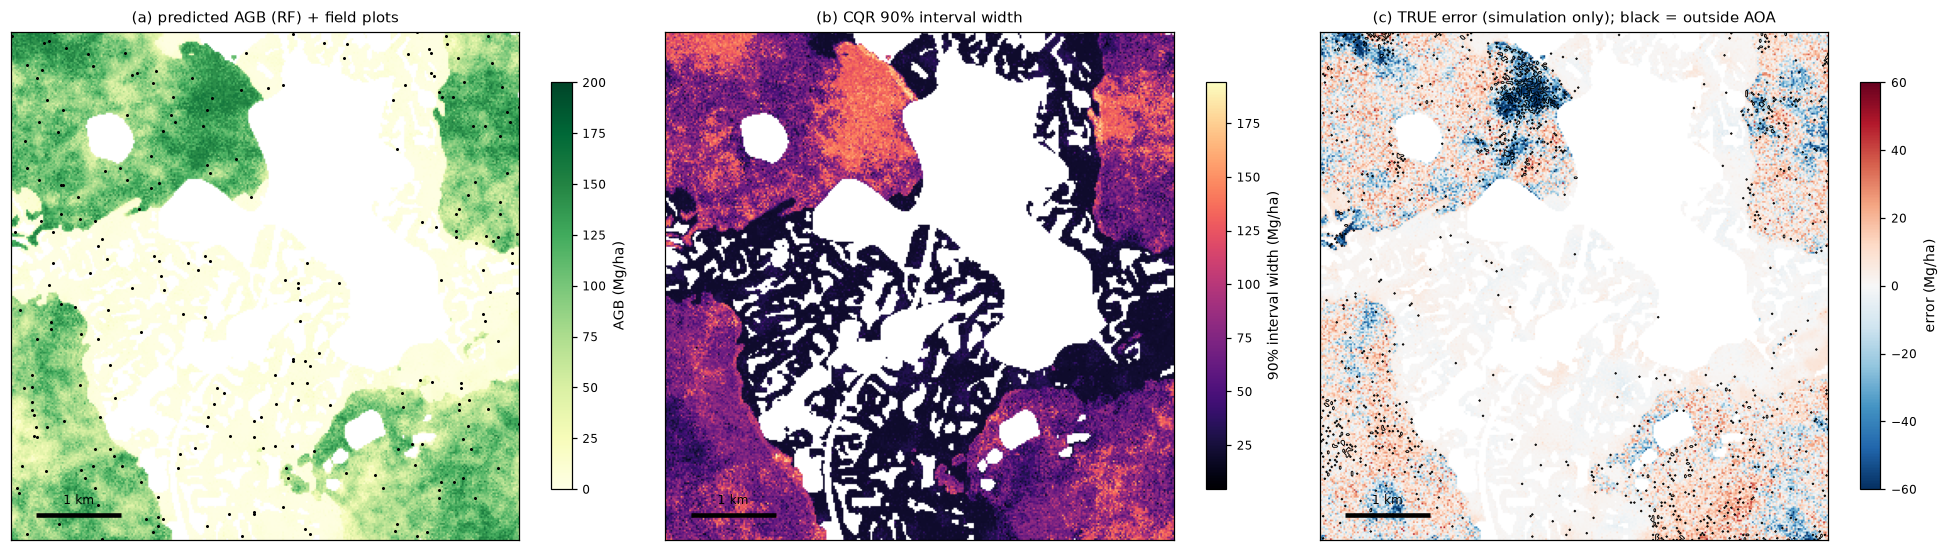

inside AOA: 97.7% of the wooded area | RMSE vs truth inside 14.0, outside 29.9 Mg/ha


In [6]:
grid = np.stack([Pr[f].ravel() for f in feat_all], 1)
blk = np.unique(groups); cal_blk = rng.choice(blk, len(blk) // 4, replace=False); cal = np.isin(groups, cal_blk)
rf_final = RandomForestRegressor(500, min_samples_leaf=3, max_features=0.5, oob_score=True, n_jobs=-1, random_state=SEED).fit(X, y)
lo_m, hi_m = qlgb(ALPHA / 2).fit(X[~cal], y[~cal]), qlgb(1 - ALPHA / 2).fit(X[~cal], y[~cal])
qc = conformal_q(np.maximum(lo_m.predict(X[cal]) - y[cal], y[cal] - hi_m.predict(X[cal])), ALPHA)
agb_map = np.where(wooded.ravel(), rf_final.predict(grid), 0).reshape(H, W)
width = np.where(wooded.ravel(), np.clip(hi_m.predict(grid) + qc, 0, None) - np.clip(lo_m.predict(grid) - qc, 0, None), np.nan).reshape(H, W)
di, thr = ru.dissimilarity_index(X, grid, weights=rf_final.feature_importances_, cv_folds=groups % 5)
aoa = (di <= thr).reshape(H, W) | ~wooded
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
im = axes[0].imshow(np.where(wooded, agb_map, np.nan), cmap="YlGn", vmin=0, vmax=200, extent=ext); fig.colorbar(im, ax=axes[0], shrink=0.75, label="AGB (Mg/ha)")
axes[0].plot(df.x, df.y, "k.", ms=2); axes[0].set_title("(a) predicted AGB (RF) + field plots")
im = axes[1].imshow(width, cmap="magma", extent=ext); fig.colorbar(im, ax=axes[1], shrink=0.75, label="90% interval width (Mg/ha)"); axes[1].set_title("(b) CQR 90% interval width")
im = axes[2].imshow(np.where(wooded, agb_map - agb_true, np.nan), cmap="RdBu_r", vmin=-60, vmax=60, extent=ext); fig.colorbar(im, ax=axes[2], shrink=0.75, label="error (Mg/ha)")
axes[2].contour(np.linspace(ext[0], ext[1], W), np.linspace(ext[3], ext[2], H), (~aoa).astype(float), levels=[0.5], colors="k", linewidths=0.6)
axes[2].set_title("(c) TRUE error (simulation only); black = outside AOA")
for ax in axes: ax.set_xticks([]); ax.set_yticks([]); ru.add_scalebar(ax, 1000, ext)
plt.tight_layout(); fig.savefig(PROJ / "fig3_agb_maps.png", dpi=300, bbox_inches="tight"); plt.show()
print(f"inside AOA: {aoa[wooded].mean():.1%} of the wooded area | RMSE vs truth inside {np.sqrt(np.mean((agb_map - agb_true)[wooded & aoa] ** 2)):.1f}, "
      f"outside {np.sqrt(np.mean((agb_map - agb_true)[wooded & ~aoa] ** 2)) if (wooded & ~aoa).any() else float('nan'):.1f} Mg/ha")

## **5. Total AGB and Carbon: Which Estimator? (RQ3)**
Summing a map gives a total, but **not** a valid confidence interval, and map bias goes straight into the total. With a **probability sample of plots** we have two valid options (McRoberts et al. 2013; Särndal et al. 1992):
- **Design-based (plots only)**: total = A x mean(plot AGB), SE = A x sd / sqrt(n). Unbiased, but imprecise.
- **Model-assisted, GREG**: total = sum of map predictions + A x mean(plot residuals). The residual term **corrects the map's bias**, and SE = A x sd(residuals) / sqrt(n). It is still design-unbiased, and more precise when the model is good. For random forests, use **out-of-bag** predictions for the residuals: in-sample RF residuals are far too small.

Carbon = 0.47 x AGB (IPCC default carbon fraction); CO2e = C x 44/12.

In [7]:
A_ha = wooded.sum() * PIX_HA; n = len(y)
design_total, design_se = A_ha * y.mean(), A_ha * y.std(ddof=1) / np.sqrt(n)
resid = y - rf_final.oob_prediction_
map_total = agb_map[wooded].sum() * PIX_HA
greg_total = map_total + A_ha * resid.mean(); greg_se = A_ha * resid.std(ddof=1) / np.sqrt(n)
true_total = agb_true[wooded].sum() * PIX_HA
tab3 = pd.DataFrame({"total AGB (Mg)": [map_total, design_total, greg_total, true_total],
                     "95% CI half-width (Mg)": [np.nan, 1.96 * design_se, 1.96 * greg_se, np.nan]},
                    index=["map sum (no valid CI)", "design-based (plots only)", "model-assisted GREG", "TRUE (simulation only)"])
tab3["total carbon (Mg C)"] = 0.47 * tab3["total AGB (Mg)"]; tab3["CO2e (Mg)"] = tab3["total carbon (Mg C)"] * 44 / 12
tab3["relative 95% CI %"] = 100 * tab3["95% CI half-width (Mg)"] / tab3["total AGB (Mg)"]
tab3.round(0).to_csv(PROJ / "table3_totals.csv")
print(f"relative efficiency of GREG over design-based: {(design_se / greg_se) ** 2:.1f}x (the plot sample size the map 'saves')")
tab3.round(1)

relative efficiency of GREG over design-based: 6.5x (the plot sample size the map 'saves')


,total AGB (Mg),95% CI half-width (Mg),total carbon (Mg C),CO2e (Mg),relative 95% CI %
map sum (no valid CI),144789.7,NaN,68051.1,249520.9,NaN
design-based (plots only),141489.7,17078.9,66500.2,243834.0,12.1
model-assisted GREG,144959.6,6719.3,68131.0,249813.6,4.6
TRUE (simulation only),144526.9,NaN,67927.6,249068.0,NaN


# **Part 2: Going Deeper**

## **6. Why Summing Pixel Variances Is Wrong, and a Bootstrap Alternative**
A tempting shortcut: treat each pixel's prediction error as independent, so Var(total) = sum of pixel variances. Pixel errors are strongly **correlated**, though: the same model bias affects every pixel with similar predictors. The shortcut therefore produces absurdly narrow intervals. A model-based alternative is to **bootstrap the plots**, refit the whole model, recompute the map total each time (capturing model uncertainty), and add the residual (bias-correction) uncertainty.

In [8]:
pix_var = (width[wooded] / (2 * 1.645)) ** 2                                       # per-pixel variance from the 90% interval
naive_se = np.sqrt(np.sum(pix_var)) * PIX_HA
boot_totals = []
for b in range(30):
    i = rng.integers(0, n, n)
    m = RandomForestRegressor(200, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=b).fit(X[i], y[i])
    boot_totals.append(m.predict(grid[wooded.ravel()]).sum() * PIX_HA)
boot_se = np.std(boot_totals, ddof=1)
print(f"naive independent-pixel SE: {naive_se:,.0f} Mg ({100 * naive_se / map_total:.2f}% of total)  <- far too small")
print(f"bootstrap model SE: {boot_se:,.0f} Mg | GREG SE: {greg_se:,.0f} Mg | |map - TRUE| = {abs(map_total - true_total):,.0f} Mg | |GREG - TRUE| = {abs(greg_total - true_total):,.0f} Mg")

naive independent-pixel SE: 210 Mg (0.15% of total)  <- far too small
bootstrap model SE: 2,681 Mg | GREG SE: 3,428 Mg | |map - TRUE| = 263 Mg | |GREG - TRUE| = 433 Mg


The bootstrap captures how much the **model** varies, but not the systematic map bias, which GREG corrects using the plots. In a paper, report the GREG (or another design-based) estimate as the headline number, and the map as a spatial distribution.

## **Practice Problems**
1. Train RF on log(AGB + 1) and back-transform. Does it reduce the under-prediction of the highest AGB class?
2. Compute rRMSE for AGB < 50, 50-100 and > 100 Mg/ha. Where is the map most useful?
3. Repeat the CQR evaluation for 80% intervals. Is coverage still close to the target?
4. *(Advanced)* Use LightGBM (with its own out-of-fold residuals from 5-fold spatial CV) in the GREG estimator. Compare its SE with the RF version.

In [9]:
# Solution 1
p_log = np.zeros(n)
for tr, te in folds: p_log[te] = np.expm1(model_defs["random forest"]().fit(X[tr], np.log1p(y[tr])).predict(X[te]))
hi = y > 100
print(f"bias for AGB > 100: raw RF {np.mean(oof[('random forest', 'S1+S2+CHM')][hi] - y[hi]):.1f} | log-RF {np.mean(p_log[hi] - y[hi]):.1f} Mg/ha")

bias for AGB > 100: raw RF -18.2 | log-RF -24.7 Mg/ha


In [10]:
# Solution 2
for lo_, hi_ in [(0, 50), (50, 100), (100, 1000)]:
    m = (y >= lo_) & (y < hi_); p = oof[best_key][m]
    print(f"{lo_:>3}-{hi_:<4} Mg/ha: n {m.sum():>3}, rRMSE {100 * np.sqrt(np.mean((p - y[m]) ** 2)) / y[m].mean():.1f}%")

  0-50   Mg/ha: n 124, rRMSE 122.0%
 50-100  Mg/ha: n  67, rRMSE 28.0%
100-1000 Mg/ha: n  59, rRMSE 25.2%


In [11]:
# Solution 3
cov80 = []
for tr, te in folds:
    blk_ = np.unique(groups[tr]); cb = rng.choice(blk_, max(1, len(blk_) // 4), replace=False)
    cal_, prop_ = tr[np.isin(groups[tr], cb)], tr[~np.isin(groups[tr], cb)]
    lo_q, hi_q = qlgb(0.1).fit(X[prop_], y[prop_]), qlgb(0.9).fit(X[prop_], y[prop_])
    q_ = conformal_q(np.maximum(lo_q.predict(X[cal_]) - y[cal_], y[cal_] - hi_q.predict(X[cal_])), 0.2)
    cov80.append(np.mean((y[te] >= lo_q.predict(X[te]) - q_) & (y[te] <= hi_q.predict(X[te]) + q_)))
print(f"CQR 80% intervals: coverage {np.mean(cov80):.3f} (+/- {np.std(cov80):.3f} over spatial folds)")

CQR 80% intervals: coverage 0.815 (+/- 0.066 over spatial folds)


In [12]:
# Solution 4
oof_lgb = np.zeros(n)
for tr, te in folds: oof_lgb[te] = model_defs["LightGBM"]().fit(X[tr], y[tr]).predict(X[te])
lgb_full = model_defs["LightGBM"]().fit(X, y)
tot_lgb = np.where(wooded.ravel(), lgb_full.predict(grid), 0).sum() * PIX_HA + A_ha * (y - oof_lgb).mean()
se_lgb = A_ha * (y - oof_lgb).std(ddof=1) / np.sqrt(n)
print(f"GREG-LightGBM total {tot_lgb:,.0f} +/- {1.96 * se_lgb:,.0f} Mg | GREG-RF {greg_total:,.0f} +/- {1.96 * greg_se:,.0f} Mg | TRUE {true_total:,.0f} Mg")

GREG-LightGBM total 144,537 +/- 6,801 Mg | GREG-RF 144,960 +/- 6,719 Mg | TRUE 144,527 Mg


## **Key References**
- Chave, J. et al. (2014). Improved allometric models to estimate the aboveground biomass of tropical trees. *Global Change Biology*, 20(10), 3177-3190.
- McRoberts, R. E., Næsset, E., & Gobakken, T. (2013). Inference for lidar-assisted estimation of forest growing stock volume. *Remote Sensing of Environment*, 128, 268-275.
- Särndal, C.-E., Swensson, B., & Wretman, J. (1992). *Model Assisted Survey Sampling*. Springer.
- Romano, Y., Patterson, E., & Candès, E. (2019). Conformalized quantile regression. *Advances in Neural Information Processing Systems*, 32.
- Meinshausen, N. (2006). Quantile regression forests. *Journal of Machine Learning Research*, 7, 983-999.
- Lang, N., Jetz, W., Schindler, K., & Wegner, J. D. (2023). A high-resolution canopy height model of the Earth. *Nature Ecology & Evolution*, 7, 1778-1789.
- Dubayah, R. et al. (2020). The Global Ecosystem Dynamics Investigation: High-resolution laser ranging of the Earth's forests and topography. *Science of Remote Sensing*, 1, 100002.
- Réjou-Méchain, M. et al. (2019). Upscaling forest biomass from field to satellite measurements: sources of errors and ways to reduce them. *Surveys in Geophysics*, 40(4), 881-911.
- IPCC (2006). *2006 IPCC Guidelines for National Greenhouse Gas Inventories*, Volume 4: Agriculture, Forestry and Other Land Use.